# Art Style Classifier

The purpose of this notebook is to create an art style classifier using a pretrained neural network, which can identify and categorize art into one of five styles:  Abstract Expressionism, Cubism, Mathematical art, Optical Illusion art or Pop art. To achieve this, we first collect and preprocess at maximum 500 images per art style using DuckDuckGo image search. Next, we fine-tune the pretrained neural network to recognize these art styles. Finally, we test the model's performance on new images to evaluate its accuracy and generalization capabilities.

Then the goal is to create a Gradio application to serve/deploy the model for user interaction.

### Steps:
#### 1. Data Collection and Preprocessing
   Use DuckDuckGo to search for images of art styles. At maximum 250 pictures per art style
   - Abstract Expressionism: Spontaneous, emotive art characterized by non-representational forms and energetic brushwork
   - Cubism: Art that deconstructs objects into geometric forms, often depicting multiple perspectives
   - Mathematical Art: Works using geometric principles, symmetry, and mathematical patterns (e.g., Escher’s style)
   - Optical Illusion Art: Art that creates perceptual tricks through ambiguous, impossible, or distorted imagery
   - Pop Art: Emerged in the mid-20th century, drawing on imagery from popular culture (e.g., advertising, comic books, everyday objects), often employing bright colors and mechanical or mass-production techniques
   
#### 2. Model Training, and Evaluation
##### Training:
* Convolutional Neural Network (CNN): Fine-tune a ResNet50 model as a baseline
* Vision Transformer (ViT): Fine-tune a model such as ViT-B/32 to capture global features
* Zero-Shot Multimodal Model CLIP: Leverage pre-trained CLIP for inference using text prompts
* Fine-Tuned Multimodal Model CLIP: Adapt CLIP further on our dataset for improved performance

##### Process:
1. Fine-tune the pretrained networks on the art style dataset
2. Evaluate the model's performance on a test set

#### 2. Inference, and Deployment
##### Inference Models
+ ResNet50 (CNN)
+ Vision Transformer (ViT)
+ Zero-Shot CLIP
+ Fine-Tuned CLIP




### Step 1: Get Data

In [39]:
# import libraries
from fastcore.all import *
from fastai.vision.all import *
from fastdownload import download_url
# from duckduckgo_search import ddg_imagesddg
from tkinter import Image
from time import sleep
import requests
from bs4 import BeautifulSoup
from PIL import Image
from io import BytesIO
from IPython.display import display, HTML
import os
from PIL import Image, UnidentifiedImageError
from io import BytesIO
import matplotlib.pyplot as plt
from duckduckgo_search import DDGS
from pathlib import Path

import os
from collections import defaultdict
import pandas as pd
from pathlib import Path

In [40]:
# duckduckgo search function
def search_duckduckgo_image(query, max_images=1):
    """search for image URLs using DuckDuckGo."""
    with DDGS() as ddgs:
        results = list(ddgs.images(f'{query} art photo', max_results=max_images))
    return [img['image'] for img in results] if results else None

def process_image(query, art, max_images=1, test=True):
    """process the image search, download, resize, and display/save."""
    urls = search_duckduckgo_image(query, max_images)
    if not urls:
        print("No images found.")
        return

    for i, url in enumerate(urls):
        # download image from url
        headers = {
                "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
            }

        try:
            response = requests.get(url, headers=headers, timeout=5)
            response.raise_for_status()  # ensure we got a valid response
            image = Image.open(BytesIO(response.content))
            image.verify()  # check if the image is valid
            image = Image.open(BytesIO(response.content))  # reopen after verification
        except (requests.exceptions.RequestException, UnidentifiedImageError) as e:
            print(f"Skipping invalid image: {e}")
            continue
    
        # resize image
        resized_image = image.resize((192, 192))

        if test:
            # display image
            print(f'{query}')
            display(resized_image)

            # saving image in sample folder
            resized_image.convert("RGB").save(os.path.join(f'images/sample/{art}', f'{query}_{i}.jpg'))


        else:
            # saving image in sample folder
            resized_image.convert("RGB").save(os.path.join(f'images/training/{art}', f'{query}_{i}.jpg'))
            print(f"Searching for {query} image {i+1} of {max_images}.")

abstract expressionism


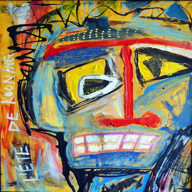

abstract expressionism


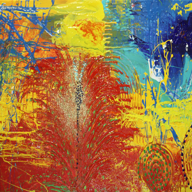

In [41]:
# testing abstract expressionism
if __name__ == "__main__":
    process_image('abstract expressionism', 'abstract expressionism', max_images=2, test=True)

cubism


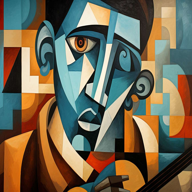

cubism


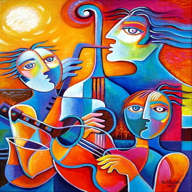

In [42]:
# testing cubism 
if __name__ == "__main__":
    process_image('cubism', 'cubism', max_images=2, test=True)

mathematical


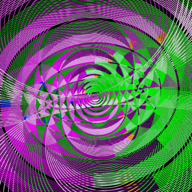

mathematical


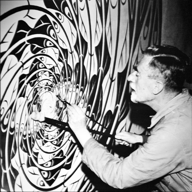

In [43]:
# testing cubism 
if __name__ == "__main__":
    process_image('mathematical', 'mathematical', max_images=2, test=True)

optical illusion


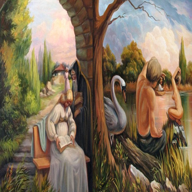

optical illusion


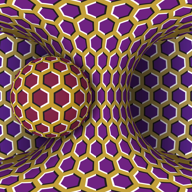

In [44]:
# testing optical illusion
if __name__ == "__main__":
    process_image('optical illusion', 'optical illusion', max_images=2, test=True)

pop


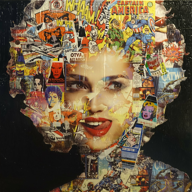

pop


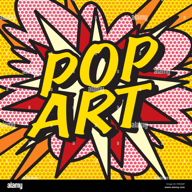

In [45]:
# testing pop art
if __name__ == "__main__":
    process_image('pop', 'pop', max_images=2, test=True)

In [46]:
# data 
art_style_data = {
    'abstract expressionism': ['abstract expressionism'],
    'cubism': ['cubism'],
    'mathematical': ['mathematical'],
    'optical illusion': ['optical illusion'],
    'pop': ['pop']
}

# function to collect images
def collect_images(dict_data):
    """collect 550 images per art style in the dictionary."""
    for key, value in dict_data.items():
        for i in value:
            process_image(i, key, max_images=550, test=False)

In [4]:
# collect images
collect_images(art_style_data)

Searching for abstract expressionism image 1 of 550.
Searching for abstract expressionism image 2 of 550.
Skipping invalid image: 403 Client Error: Forbidden for url: https://www.artmajeur.com/medias/hd/r/e/retne/artwork/12478196_abstract-painting-untitled-abstraction-1.jpg
Searching for abstract expressionism image 4 of 550.
Searching for abstract expressionism image 5 of 550.
Searching for abstract expressionism image 6 of 550.
Searching for abstract expressionism image 7 of 550.
Searching for abstract expressionism image 8 of 550.
Searching for abstract expressionism image 9 of 550.
Searching for abstract expressionism image 10 of 550.
Searching for abstract expressionism image 11 of 550.
Searching for abstract expressionism image 12 of 550.
Searching for abstract expressionism image 13 of 550.
Searching for abstract expressionism image 14 of 550.
Skipping invalid image: 403 Client Error: Forbidden for url: https://www.artmajeur.com/medias/hd/r/e/retne/artwork/12478196_3_abstract-pa

c:\Users\roger\AppData\Local\Programs\Python\Python310\lib\site-packages\PIL\Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Searching for abstract expressionism image 340 of 550.
Searching for abstract expressionism image 341 of 550.
Searching for abstract expressionism image 342 of 550.
Searching for abstract expressionism image 343 of 550.
Searching for abstract expressionism image 344 of 550.
Searching for abstract expressionism image 345 of 550.
Searching for abstract expressionism image 346 of 550.
Searching for abstract expressionism image 347 of 550.
Searching for abstract expressionism image 348 of 550.
Searching for abstract expressionism image 349 of 550.
Searching for abstract expressionism image 350 of 550.
Searching for abstract expressionism image 351 of 550.
Searching for abstract expressionism image 352 of 550.
Searching for abstract expressionism image 353 of 550.
Searching for abstract expressionism image 354 of 550.
Searching for abstract expressionism image 355 of 550.
Searching for abstract expressionism image 356 of 550.
Searching for abstract expressionism image 357 of 550.
Searching 

In [54]:
# data splitting
import os
import random
import pandas as pd
from collections import defaultdict
from sklearn.model_selection import train_test_split

# move files into train/val folders and load data using pytorch
import shutil
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm

In [48]:
# function to count images per subcategory to test the distribution of images collected
def count_images_per_subcategory(data_dir, class_mapping):
    """count the number of images per subcategory in a dataset."""

    data_dir = Path(data_dir)
    counts = []

    # itterate through each class and its subcategories
    for class_name, subcategories in class_mapping.items():
        class_path = data_dir / class_name
        
        if class_path.is_dir():
            for subcategory in subcategories:
                # find all images that match the subcategory naming pattern
                subcat_images = list(class_path.glob(f"{subcategory}_*.jpg"))
                counts.append([class_name, subcategory, len(subcat_images)])

    # create a DataFrame
    df = pd.DataFrame(counts, columns=["art", "art", "count"])
    return df


In [6]:
# get the counts
df_counts = count_images_per_subcategory("images/training", art_style_data)

# view result
print(df_counts)

                      art                     art  count
0  abstract expressionism  abstract expressionism    345
1                  cubism                  cubism    431
2            mathematical            mathematical    414
3        optical illusion        optical illusion    352
4                     pop                     pop    442


In [ ]:
# dictionary to hold train/val splits
train_files = []
val_files = []

# collect images by class and subcategory
subcategory_images = defaultdict(list)

# iterate over class folders (carnivore, marsupial, etc.)
for class_name in os.listdir("images/training/"):
    class_path = os.path.join("images/training/", class_name)
    
    if os.path.isdir(class_path):
        for image_file in os.listdir(class_path):
            if image_file.endswith(".jpg"):
                subcategory = image_file.rsplit("_", 1)[0]  # extract subcategory (e.g., 'bear' from 'bear_0.jpg')
                subcategory_images[(class_name, subcategory)].append(os.path.join(class_path, image_file))

# perform a 80/20 split per subcategory
split_data = []
for (class_name, subcategory), images in subcategory_images.items():
    random.shuffle(images)  # shuffle for randomness
    train, val = train_test_split(images, test_size=0.2, random_state=42)
    
    for file in train:
        split_data.append(("train", class_name, subcategory, file))
    for file in val:
        split_data.append(("val", class_name, subcategory, file))

# convert to dataframe for verification
split_df = pd.DataFrame(split_data, columns=["set", "class", "subcategory", "file"])

# summarize the counts
summary_table = split_df.groupby(["set", "class", "subcategory"]).size().reset_index(name="count")

# display summary of train/val counts per class & subcategory
print(summary_table)


     set                   class             subcategory  count
0  train  abstract expressionism  abstract expressionism    276
1  train                  cubism                  cubism    344
2  train            mathematical            mathematical    331
3  train        optical illusion        optical illusion    281
4  train                     pop                     pop    353
5    val  abstract expressionism  abstract expressionism     69
6    val                  cubism                  cubism     87
7    val            mathematical            mathematical     83
8    val        optical illusion        optical illusion     71
9    val                     pop                     pop     89


In [49]:
# move images from images/training to train and val folders under dataset
train_path = os.path.join("dataset", "train")
val_path = os.path.join("dataset", "val")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
# create train/val directories
for path in [train_path, val_path]:
    os.makedirs(path, exist_ok=True)

# move images into correct train/val directories
for _, row in split_df.iterrows():
    dataset_type, class_name, subcategory, file_path = row["set"], row["class"], row["subcategory"], row["file"]
    
    # destination path
    dest_folder = os.path.join("dataset", dataset_type, class_name)
    os.makedirs(dest_folder, exist_ok=True)
    
    # move file
    shutil.move(file_path, os.path.join(dest_folder, os.path.basename(file_path)))

print("Files successfully moved into structured dataset format.")


Files successfully moved into structured dataset format.


In [57]:
# data augmentation function
def get_data_transforms(augmentation=True):
    """return training and validation transforms based on augmentation choice."""
    
    if augmentation:
        train_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(20),
            transforms.RandomAffine(15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
    else:
        train_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    return train_transform, val_transform


## Step 2: Train the Model

In [58]:
# training model
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm
import time

# visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import random


In [59]:
# define normal transforms and augmentation transforms
train_transform, val_transform = get_data_transforms(augmentation=False)
train_tranform_augmented, val_transform_augmented = get_data_transforms(augmentation=True)

# load datasets
train_dataset = datasets.ImageFolder(root=train_path, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_path, transform=val_transform)
train_dataset_augmented = datasets.ImageFolder(root=train_path, transform=train_tranform_augmented)
val_dataset_augmented = datasets.ImageFolder(root=val_path, transform=val_transform_augmented)

# create data loaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)
train_loader_augmented = torch.utils.data.DataLoader(train_dataset_augmented, batch_size=32, shuffle=True)

# verify class mappings
print("class index mapping:")
print(train_dataset.class_to_idx)
print('')
print('data summary:')
print(f"total | {len(train_dataset) + len(val_dataset)}")
print(f"train | {len(train_dataset)}")
print(f"val   | {len(val_dataset)}")

class index mapping:
{'abstract expressionism': 0, 'cubism': 1, 'mathematical': 2, 'optical illusion': 3, 'pop': 4}

data summary:
total | 1984
train | 1585
val   | 399


In [60]:
# ---------------------------- initialize model ----------------------------
def initialize_model(model_name, num_classes, device):
    """
    load and customize a pretrained model by name (resnet or vit).
    """
    # check if model is a resnet
    if model_name.startswith("resnet"):
        # load a torchvision resnet
        model = getattr(models, model_name)(pretrained=True)
        # replace its final layer
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    else:
        # load a timm model (assume vit)
        model = timm.create_model(model_name, pretrained=True)
        # replace final layer
        if hasattr(model, "head") and isinstance(model.head, nn.Linear):
            model.head = nn.Linear(model.head.in_features, num_classes)
        else:
            raise ValueError(f"unsupported final layer for model: {model_name}")
        
    return model.to(device)


# ---------------------------- optimizer & loss ----------------------------
def get_optimizer_and_loss(model, lr):
    """return the loss function and optimizer."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    return criterion, optimizer

# ---------------------------- training function ----------------------------
def train_model(model_name, train_loader, num_classes, num_epochs, lr, device):
    """train a model with given dataset and hyperparameters."""

    # initialize model
    model = initialize_model(model_name, num_classes, device)

    # define loss and optimizer
    criterion, optimizer = get_optimizer_and_loss(model, lr)

    # learning rate scheduler
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.7)

    # training loop
    model.train()
    loss_history = []
    start_time = time.time()

    for epoch in range(num_epochs):
        total_loss = 0.0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)

        print(f"epoch {epoch+1}: loss = {avg_loss:.4f}, lr = {scheduler.get_last_lr()[0]:.6f}")
        scheduler.step()

    training_time = time.time() - start_time
    print(f"\ntraining complete! time taken: {training_time:.2f} sec\n")

    return model, loss_history, training_time



# ---------------------------- evaluation function ----------------------------
def evaluate_model(model, val_loader, device):
    """Evaluate the trained model on a validation dataset."""
    
    model.eval()
    correct, total = 0, 0
    loss_total = 0.0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_total += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    avg_loss = loss_total / len(val_loader)

    return accuracy, avg_loss, total, correct

def validation_output(accuracy, avg_loss, total, correct):
    # print metrics in a structured format
    print("Validation Results")
    print("-"*30)
    print(f"Total Images Tested:         {total}")
    print(f"Images Predicted Correctly:  {correct}")
    print(f"Validation Accuracy:         {accuracy:.2f}%")
    print(f"Validation Loss:             {avg_loss:.4f}")



### Step 2: Train, Clean & Test the Model

##### Resnet18

In [15]:
# train resnet18
resnet_model, loss_history, training_time = train_model(
    model_name="resnet18",
    train_loader=train_loader,
    num_classes=5,  
    num_epochs=15,
    lr=0.001,
    device=device
)

c:\Users\roger\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\roger\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/15: 100%|██████████| 50/50 [01:12<00:00,  1.45s/it]


epoch 1: loss = 1.3056, lr = 0.001000


Epoch 2/15: 100%|██████████| 50/50 [00:59<00:00,  1.19s/it]


epoch 2: loss = 0.8937, lr = 0.001000


Epoch 3/15: 100%|██████████| 50/50 [00:59<00:00,  1.20s/it]


...

epoch 13: loss = 0.0762, lr = 0.000490


Epoch 14/15: 100%|██████████| 50/50 [01:19<00:00,  1.58s/it]


epoch 14: loss = 0.0534, lr = 0.000490


Epoch 15/15: 100%|██████████| 50/50 [01:20<00:00,  1.61s/it]

epoch 15: loss = 0.0276, lr = 0.000490

training complete! time taken: 1213.48 sec



In [ ]:
# train resnet18 augmented
resnet_aug_model, loss_history, training_time = train_model(
    model_name="resnet18",
    train_loader=train_loader_augmented,
    num_classes=5,  
    num_epochs=15,
    lr=0.001,
    device=device
)

Epoch 1/15: 100%|██████████| 50/50 [01:26<00:00,  1.73s/it]


epoch 1: loss = 1.4107, lr = 0.001000


Epoch 2/15: 100%|██████████| 50/50 [01:21<00:00,  1.64s/it]


epoch 2: loss = 1.1264, lr = 0.001000


Epoch 3/15: 100%|██████████| 50/50 [01:21<00:00,  1.63s/it]


...

epoch 13: loss = 0.3748, lr = 0.000490


Epoch 14/15: 100%|██████████| 50/50 [01:06<00:00,  1.32s/it]


epoch 14: loss = 0.3646, lr = 0.000490


Epoch 15/15: 100%|██████████| 50/50 [01:04<00:00,  1.29s/it]

epoch 15: loss = 0.3999, lr = 0.000490

training complete! time taken: 1081.17 sec



##### Resnet34

In [20]:
# train resnet34
resnet34_model, loss_history, training_time = train_model(
    model_name="resnet34",
    train_loader=train_loader,
    num_classes=5,  
    num_epochs=15,
    lr=0.001,
    device=device
)

c:\Users\roger\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\roger\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\roger/.cache\torch\hub\checkpoints\resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [01:37<00:00, 893kB/s] 
Epoch 1/15: 100%|██████████| 50/50 [02:21<00:00,  2.82s/it]


epoch 1: loss = 1.5483, lr = 0.001000


Epoch 2/15: 100%|██████████| 50/50 [01:56<00:00,  2.33s/it]


epoch 2: loss = 1.1729, lr = 0.001000


Epoch 3/15: 100%|██████████| 50/50 [02:09<00:00,  2.59s/it]


...

epoch 13: loss = 0.1180, lr = 0.000490


Epoch 14/15: 100%|██████████| 50/50 [02:16<00:00,  2.73s/it]


epoch 14: loss = 0.0857, lr = 0.000490


Epoch 15/15: 100%|██████████| 50/50 [02:20<00:00,  2.81s/it]

epoch 15: loss = 0.1291, lr = 0.000490

training complete! time taken: 2044.17 sec



In [22]:
# train resnet34 augmented
resnet34_aug_model, loss_history, training_time = train_model(
    model_name="resnet34",
    train_loader=train_loader_augmented,
    num_classes=5,  
    num_epochs=15,
    lr=0.001,
    device=device
)

Epoch 1/15: 100%|██████████| 50/50 [02:26<00:00,  2.92s/it]


epoch 1: loss = 1.5056, lr = 0.001000


Epoch 2/15: 100%|██████████| 50/50 [02:53<00:00,  3.46s/it]


epoch 2: loss = 1.2594, lr = 0.001000


Epoch 3/15: 100%|██████████| 50/50 [02:41<00:00,  3.22s/it]


...

epoch 13: loss = 0.5463, lr = 0.000490


Epoch 14/15: 100%|██████████| 50/50 [01:56<00:00,  2.32s/it]


epoch 14: loss = 0.5625, lr = 0.000490


Epoch 15/15: 100%|██████████| 50/50 [04:56<00:00,  5.93s/it]

epoch 15: loss = 0.5666, lr = 0.000490

training complete! time taken: 2195.25 sec



##### Vit

In [61]:
# train vit_base_patch16_224
vit_model, loss_history, training_time = train_model(
    model_name="vit_base_patch16_224",
    train_loader=train_loader,
    num_classes=5,  
    num_epochs=20,
    lr=0.0001,
    device=device
)

Epoch 1/20: 100%|██████████| 50/50 [15:44<00:00, 18.89s/it]


epoch 1: loss = 1.0568, lr = 0.000100


Epoch 2/20: 100%|██████████| 50/50 [14:12<00:00, 17.04s/it]


epoch 2: loss = 0.4132, lr = 0.000100


Epoch 3/20: 100%|██████████| 50/50 [17:59<00:00, 21.60s/it] 


...

epoch 18: loss = 0.0001, lr = 0.000034


Epoch 19/20: 100%|██████████| 50/50 [20:44<00:00, 24.88s/it] 


epoch 19: loss = 0.0001, lr = 0.000034


Epoch 20/20: 100%|██████████| 50/50 [34:25<00:00, 41.31s/it]   

epoch 20: loss = 0.0001, lr = 0.000034

training complete! time taken: 16945.73 sec



## Test the model

In [64]:
# import interpretation functions
import importlib
import sys
sys.path.append('..')
import utils.custom_interpretation
importlib.reload(utils.custom_interpretation)

from utils.custom_interpretation import CustomInterpretation

### ResNet

In [17]:
# evaluate resnet18 model 
resnet18_eval = evaluate_model(
    resnet_model, 
    val_loader, 
    device=device)

validation_output(*resnet18_eval)

Validation Results
------------------------------
Total Images Tested:         399
Images Predicted Correctly:  303
Validation Accuracy:         75.94%
Validation Loss:             1.1362


In [19]:
# evaluate resnet18 augmented model 
resnet18_aug_eval = evaluate_model(
    resnet_aug_model, 
    val_loader, 
    device=device)

validation_output(*resnet18_aug_eval)

Validation Results
------------------------------
Total Images Tested:         399
Images Predicted Correctly:  280
Validation Accuracy:         70.18%
Validation Loss:             1.0507


In [21]:
# evaluate resnet34 model 
resnet34_eval = evaluate_model(
    resnet34_model, 
    val_loader, 
    device=device)

validation_output(*resnet34_eval)

Validation Results
------------------------------
Total Images Tested:         399
Images Predicted Correctly:  292
Validation Accuracy:         73.18%
Validation Loss:             1.1908


In [23]:
# evaluate resnet34 augmented model 
resnet34_aug_eval = evaluate_model(
    resnet34_aug_model, 
    val_loader, 
    device=device)

validation_output(*resnet34_aug_eval)

Validation Results
------------------------------
Total Images Tested:         399
Images Predicted Correctly:  279
Validation Accuracy:         69.92%
Validation Loss:             0.9147


In [62]:
# evaluate vit model 
vit_eval = evaluate_model(
    vit_model, 
    val_loader, 
    device=device)

validation_output(*vit_eval)

Validation Results
------------------------------
Total Images Tested:         399
Images Predicted Correctly:  323
Validation Accuracy:         80.95%
Validation Loss:             1.0021


#### ResNet

In [18]:
# resnet interpretaion instance
interp_resnet = CustomInterpretation.from_model(
    resnet_model, 
    val_loader, 
    device, 
    train_dataset.classes)

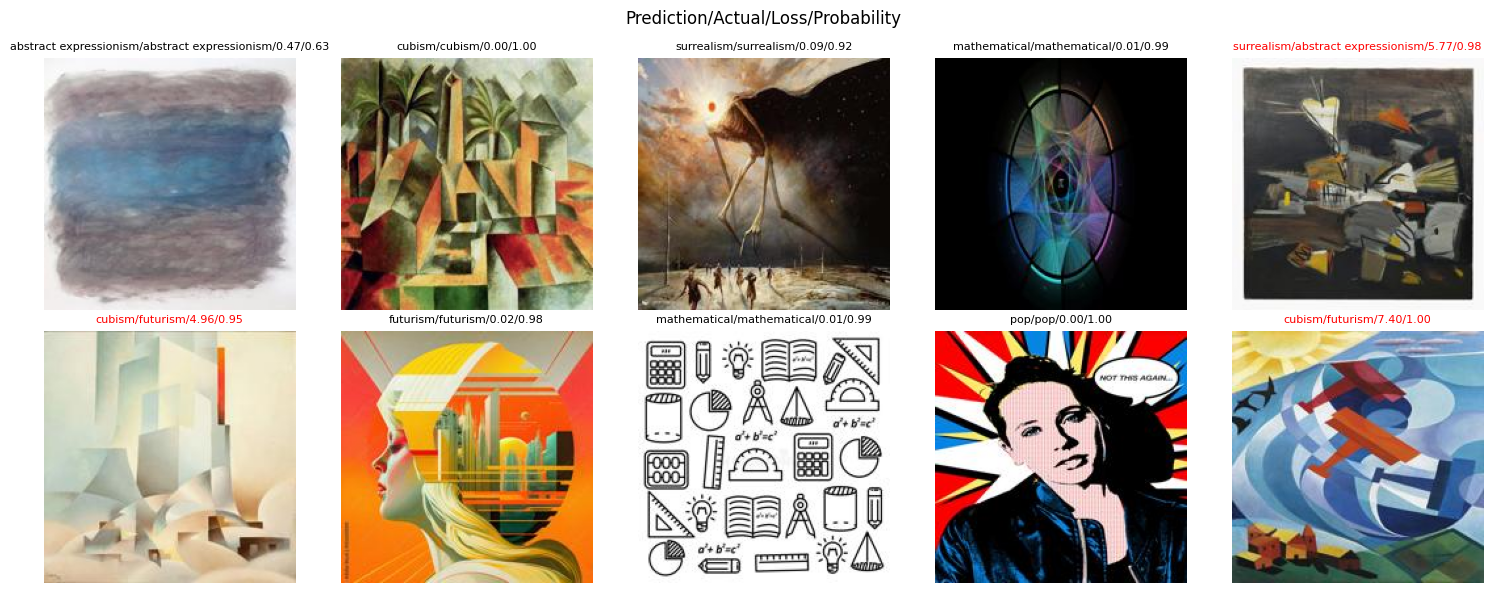

In [19]:
# plot random predictions
interp_resnet.plot_random_predictions(n=10, cols=5)

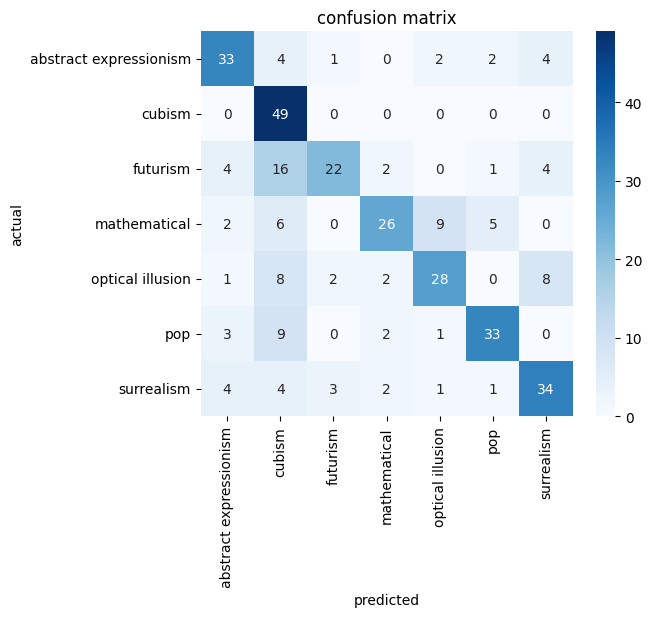

In [20]:
# plot confusion matrix
interp_resnet.plot_confusion_matrix()


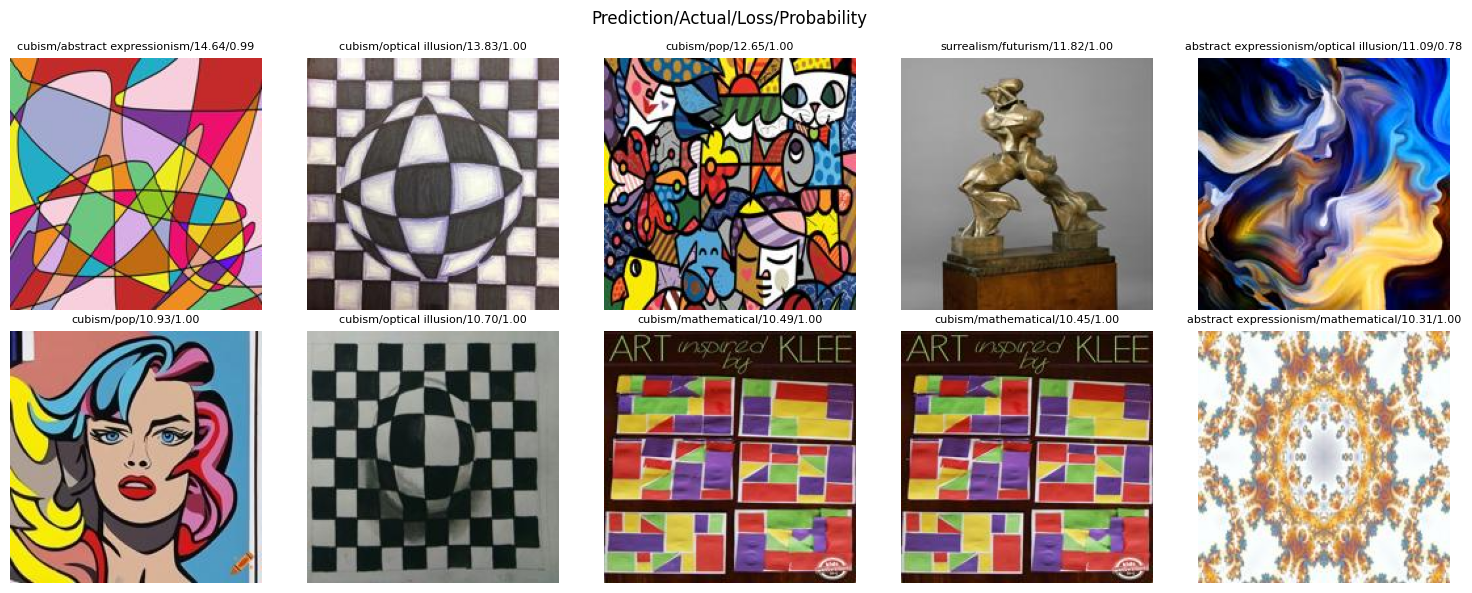

In [21]:
# plot top losses 
interp_resnet.plot_top_losses(k=10, largest=True, cols=5)

#### ViT

In [65]:
# vit interpretaion instance
interp_vit = CustomInterpretation.from_model(
    vit_model, 
    val_loader, 
    device, 
    train_dataset.classes)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6897851..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].
Clipping input d

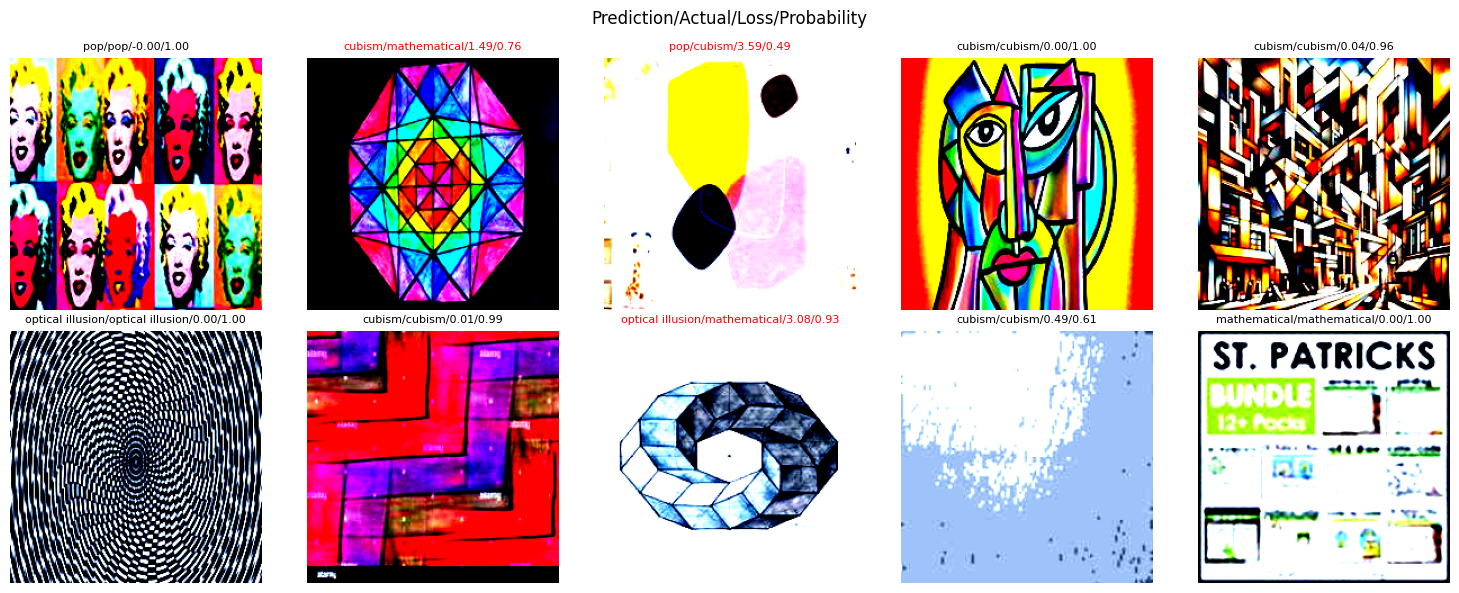

In [66]:
# plot random predictions
interp_vit.plot_random_predictions(n=10, cols=5)

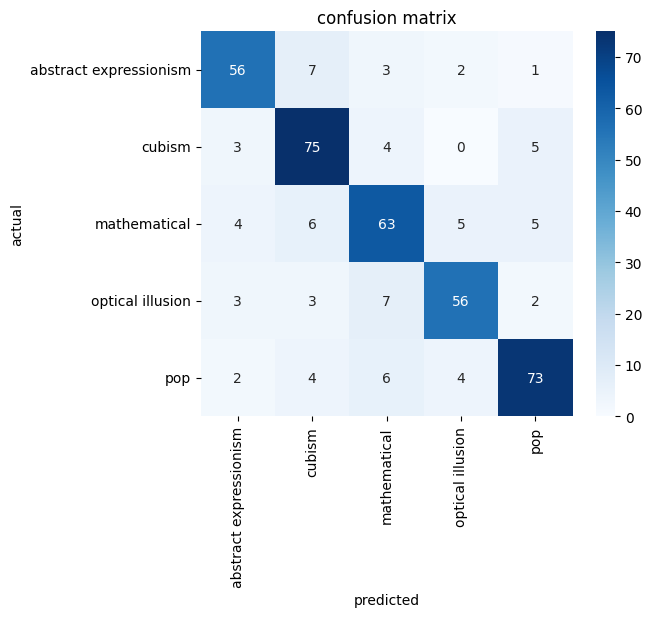

In [67]:
# plot confusion matrix
interp_vit.plot_confusion_matrix()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384109..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..-1.8044444].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4500387..2.64].
Clipping input da

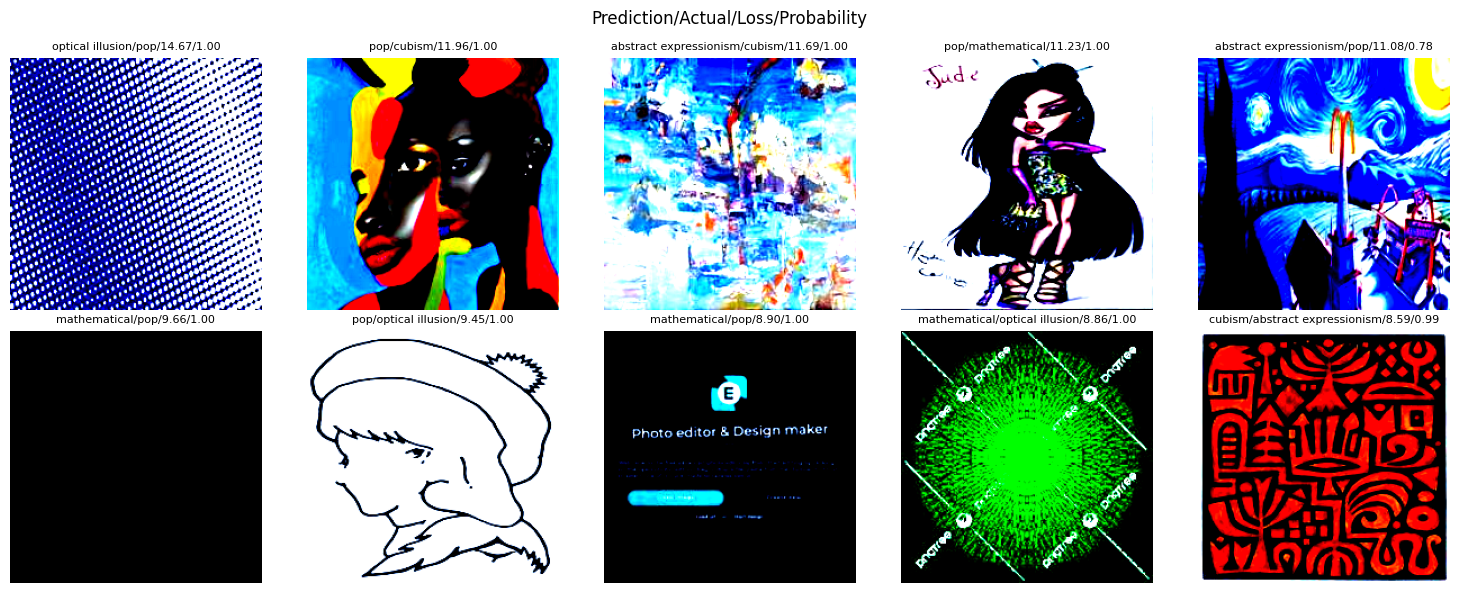

In [68]:
# plot top losses 
interp_vit.plot_top_losses(k=10, largest=True, cols=5)

In [69]:
# save pickled files
import os
import pickle

# models
model_list = [
    (resnet_model, "resnet18"),
    (resnet_aug_model, "resnet18_aug"),
    (resnet34_model, "resnet34"),
    (resnet34_aug_model, "resnet34_aug"),
    (vit_model, "vit_base")
]

# save in models directory
save_dir = "app/models"  
os.makedirs(save_dir, exist_ok=True)

# loop through models and save
for model, name in model_list:
    file_path = os.path.join(save_dir, f"art_style_{name}.pkl")
    with open(file_path, "wb") as f:
        pickle.dump(model, f)
    print(f"saved {name} model to {file_path}")

saved resnet18 model to app/models\art_style_resnet18.pkl
saved resnet18_aug model to app/models\art_style_resnet18_aug.pkl
saved resnet34 model to app/models\art_style_resnet34.pkl
saved resnet34_aug model to app/models\art_style_resnet34_aug.pkl
saved vit_base model to app/models\art_style_vit_base.pkl
